# Projeto 2 - IIA 2025/1
### YOLOv11 para Detecção de Árvores
Autor: Luiz Soaris - 190092025, Amanda Reis - 200072790

## 🔧 Clonar YOLOv11

In [ ]:
!git clone https://github.com/ultralytics/yolo
%cd yolo
!pip install -e .
%cd /content

Cloning into 'yolo'...
remote: Enumerating objects: 4244, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 4244 (delta 78), reused 43 (delta 43), pack-reused 4151 (from 2)
Receiving objects: 100% (4244/4244), 61.47 MiB | 14.92 MiB/s, done.
Resolving deltas: 100% (3096/3096), done.
/content/yolo
Obtaining file:///content/yolo
ERROR: file:///content/yolo does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
/content


## 🌳 Clonar o Dataset de Árvores Urbanas

In [ ]:
!git clone https://github.com/pedrozamboni/individual_urban_tree_crown_detection
!ls individual_urban_tree_crown_detection

Cloning into 'individual_urban_tree_crown_detection'...
remote: Enumerating objects: 696, done.
remote: Total 696 (delta 0), reused 0 (delta 0), pack-reused 696 (from 1)
Receiving objects: 100% (696/696), 184.86 MiB | 15.38 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Updating files: 100% (677/677), done.
bbox_txt  gt  img_list	MMdetecion_v_2_0.ipynb	README	rgb


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 59.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

## 📁 Criar Estrutura de Diretórios

In [ ]:
import os
for split in ['train', 'val', 'test']:
    os.makedirs(f'data/images/{split}', exist_ok=True)
    os.makedirs(f'data/labels/{split}', exist_ok=True)
print('Pastas criadas.')

Pastas criadas.


## 🔄 Converter Anotações para Formato YOLO

In [ ]:
IMG_WIDTH, IMG_HEIGHT = 512, 512
INPUT_DIR = 'individual_urban_tree_crown_detection/bbox_txt'
OUTPUT_DIR = 'data/labels/train'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for filename in os.listdir(INPUT_DIR):
    if filename.endswith('.txt'):
        input_path = os.path.join(INPUT_DIR, filename)
        output_path = os.path.join(OUTPUT_DIR, filename)

        with open(input_path, 'r') as infile, open(output_path, 'w') as outfile:
            for line in infile:
                x_min, y_min, x_max, y_max = map(int, line.strip().split())
                x_center = (x_min + x_max) / 2 / IMG_WIDTH
                y_center = (y_min + y_max) / 2 / IMG_HEIGHT
                width = (x_max - x_min) / IMG_WIDTH
                height = (y_max - y_min) / IMG_HEIGHT
                outfile.write(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

print('Conversão concluída.')

Conversão concluída.


## ✂️ Dividir em Treino/Validação/Teste (com correção do erro SameFile)

In [ ]:
import random
import shutil

random.seed(42)
txt_dir = 'individual_urban_tree_crown_detection/bbox_txt'
img_dir = 'individual_urban_tree_crown_detection/gt'

all_txts = [f for f in os.listdir(txt_dir) if f.endswith('.txt')]
random.shuffle(all_txts)
n_total = len(all_txts)
n_train = int(n_total * 0.7)
n_val = int(n_total * 0.2)

splits = {
    'train': all_txts[:n_train],
    'val': all_txts[n_train:n_train + n_val],
    'test': all_txts[n_train + n_val:]
}

for split, files in splits.items():
    for f in files:
        base = os.path.splitext(f)[0]
        src_img = os.path.join(img_dir, base + '.png')
        src_lbl = os.path.join('data/labels/train', f)
        dst_img = os.path.join('data/images', split, base + '.png')
        dst_lbl = os.path.join('data/labels', split, f)

        if os.path.exists(src_img) and os.path.exists(src_lbl):
            if os.path.abspath(src_img) != os.path.abspath(dst_img):
                shutil.copyfile(src_img, dst_img)
            if os.path.abspath(src_lbl) != os.path.abspath(dst_lbl):
                shutil.copyfile(src_lbl, dst_lbl)

print('Divisão e cópia concluídas.')

Divisão e cópia concluídas.


## 📝 Criar Arquivo `data.yaml`

In [ ]:
yaml_content = '''
train: data/images/train
val: data/images/val
test: data/images/test

nc: 1
names: ['tree']
'''
with open('data.yaml', 'w') as f:
    f.write(yaml_content)
print('Arquivo data.yaml criado.')

Arquivo data.yaml criado.


## ⬇️ Baixar Pesos Pré-treinados

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(data='data.yaml', epochs=60, imgsz=640, name='teste_criacao_runs')

Ultralytics 8.3.163 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=teste_criacao_runs2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True

train: Scanning /content/data/labels/train.cache... 154 images, 1 backgrounds, 0 corrupt: 100%|██████████| 154/154 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2579.5±1656.8 MB/s, size: 432.0 KB)


val: Scanning /content/data/labels/val.cache... 44 images, 0 backgrounds, 0 corrupt: 100%|██████████| 44/44 [00:00<?, ?it/s]


...

                   all         44        706      0.996      0.969      0.985      0.972



60 epochs completed in 0.064 hours.
Optimizer stripped from runs/detect/teste_criacao_runs2/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/teste_criacao_runs2/weights/best.pt, 6.2MB

Validating runs/detect/teste_criacao_runs2/weights/best.pt...
Ultralytics 8.3.163 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  3.41it/s]


                   all         44        706      0.996      0.969      0.985      0.972
Speed: 0.2ms preprocess, 2.5ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to runs/detect/teste_criacao_runs2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f0cb03b7c90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

## 🚀 Treinar o Modelo com YOLOv11

In [ ]:
## 🚀 Novo treinamento com pesos anteriores (sem resume=True)

!yolo task=detect \
    mode=train \
    model=runs/detect/teste_criacao_runs/weights/last.pt \
    data=data.yaml \
    epochs=60 \
    imgsz=640 \
    batch=16 \
    name=arvore-yolov112-v2 \
    lr0=0.002 \
    optimizer=AdamW \
    cos_lr=True \
    dropout=0.1 \
    patience=50 \
    weight_decay=0.0002


Ultralytics 8.3.163 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/teste_criacao_runs/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=arvore-yolov112-v22, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=50, perspective=0.0, pl

## 📊 Avaliar Modelo Treinado Automaticamente

In [ ]:
!yolo task=detect \
    mode=val \
    model=runs/detect/arvore-yolov112-v2/weights/best.pt \
    data=data.yaml

Ultralytics 8.3.163 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2117.1±1336.0 MB/s, size: 432.4 KB)
val: Scanning /content/data/labels/val.cache... 44 images, 0 backgrounds, 0 corrupt: 100% 44/44 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 3/3 [00:01<00:00,  1.66it/s]
                   all         44        706      0.993      0.975      0.984      0.974
Speed: 2.9ms preprocess, 13.6ms inference, 0.0ms loss, 6.4ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
from ultralytics import YOLO
model = YOLO("runs/detect/arvore-yolov112-v2/weights/last.pt")  # exemplo de caminho

In [ ]:
results = model("mapa2.jpg", conf=0.01,save=True)


image 1/1 /content/mapa2.jpg: 384x640 7 trees, 7.1ms
Speed: 2.0ms preprocess, 7.1ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs/detect/predict16


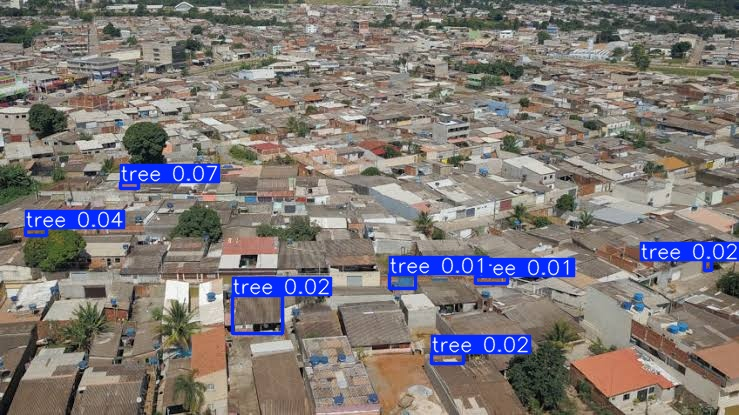

In [ ]:
ShowImage("runs/detect/predict16/mapa2.jpg")

In [ ]:
!find . -name "*.pt"

./yolov8n.pt
